In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.impute import SimpleImputer

In [ ]:
data = pd.read_csv("/content/Student Social Media And Mental Health Impact-selected-columns.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [ ]:
# Display the first 5 rows of the dataset
data.head()


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1


In [ ]:

data.shape

(5000, 10)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 390.8+ KB


In [ ]:
data.dtypes

,0
Age,int64
Gender,object
Country,object
Academic_Level,object
Most_Used_Platform,object
Purpose_Of_Use,object
Avg_Daily_Usage_Hours,float64
Daily_Unlocks,int64
Study_Hours,float64
Physical_Activity_Hours,float64


In [ ]:
data.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000
std,1.73662,1.653913,42.858254,1.637018,0.668398
min,18.00000,1.000000,62.000000,0.300000,-0.400000
25%,19.00000,3.800000,140.000000,1.500000,1.300000
50%,21.00000,5.000000,171.000000,2.800000,1.700000
75%,22.00000,6.300000,204.000000,4.200000,2.200000
max,24.00000,8.800000,273.000000,8.300000,4.100000


In [ ]:
data.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [ ]:
print("no.of duplicaterows:",data.duplicated().sum())

no.of duplicaterows: 41


In [ ]:
data.drop('Country', axis=1, inplace=True)

In [ ]:
data.isnull().sum()

,0
Age,0
Gender,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [ ]:
#create labelencoder#
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

print(data['Gender'].head())

0    1
1    0
2    1
3    1
4    0
Name: Gender, dtype: int64


In [ ]:
#One-Hot Encoding
if 'Embarked' in data.columns:
    data = pd.get_dummies(data, columns=['Embarked'])
    print("'Embarked' column one-hot encoded successfully.")
else:
    print("'Embarked' column already processed or not found.")

# Display first five rows
print(data.head())

'Embarked' column already processed or not found.
        Age  Gender Academic_Level Most_Used_Platform Purpose_Of_Use  \
0  0.500000       1  Undergraduate           Facebook     Networking   
1  0.833333       0       Graduate           LinkedIn      Education   
2  0.666667       1  Undergraduate          Instagram  Entertainment   
3  0.000000       1    High School           Snapchat  Entertainment   
4  1.000000       0       Graduate           Facebook     Networking   

   Avg_Daily_Usage_Hours  Daily_Unlocks  Study_Hours  Physical_Activity_Hours  \
0               0.384615            134          4.5                      2.2   
1               0.076923             73          7.0                      2.4   
2               0.461538            166          4.0                      1.8   
3               0.769231            220          1.0                      1.7   
4               0.833333            237          1.0                      1.1   

   Total_Activity_Hours  Is_Lo

In [ ]:
scaler=MinMaxScaler()
data[['Age','Avg_Daily_Usage_Hours']]=scaler.fit_transform(data[['Age','Avg_Daily_Usage_Hours']])
print(data[['Age','Avg_Daily_Usage_Hours']].head())

        Age  Avg_Daily_Usage_Hours
0  0.500000               0.384615
1  0.833333               0.076923
2  0.666667               0.461538
3  0.000000               0.769231
4  1.000000               0.833333


In [ ]:
data['Total_Activity_Hours'] = data['Study_Hours'] + data['Physical_Activity_Hours']
print('Total_Activity_Hours feature Created')
display(data[['Study_Hours', 'Physical_Activity_Hours', 'Total_Activity_Hours']].head())

Total_Activity_Hours feature Created


,Study_Hours,Physical_Activity_Hours,Total_Activity_Hours
0,4.5,2.2,6.7
1,7.0,2.4,9.4
2,4.0,1.8,5.8
3,1.0,1.7,2.7
4,1.0,1.1,2.1


In [ ]:
median_total_activity = data['Total_Activity_Hours'].median()
data['Is_Low_Activity'] = data['Total_Activity_Hours'].apply(lambda x: 1 if x < median_total_activity else 0)
print('Is_Low_Activity feature created')
display(data[['Total_Activity_Hours','Is_Low_Activity']].head())

Is_Low_Activity feature created


,Total_Activity_Hours,Is_Low_Activity
0,6.7,0
1,9.4,0
2,5.8,0
3,2.7,1
4,2.1,1


In [ ]:
median_daily_usage = data['Avg_Daily_Usage_Hours'].median()
data['Is_High_Usage_Hours'] = data['Avg_Daily_Usage_Hours'].apply(lambda x: 1 if x > median_daily_usage else 0)
print('Is_High_Usage_Hours feature created')
display(data[['Avg_Daily_Usage_Hours', 'Is_High_Usage_Hours']].head())

Is_High_Usage_Hours feature created


,Avg_Daily_Usage_Hours,Is_High_Usage_Hours
0,0.384615,0
1,0.076923,0
2,0.461538,0
3,0.769231,1
4,0.833333,1


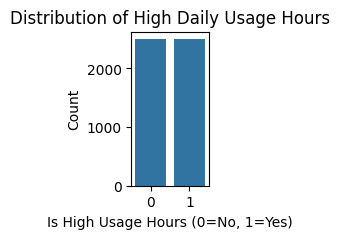

In [ ]:
plt.figure(figsize=(1,2))
sns.countplot(x='Is_High_Usage_Hours', data=data)
plt.title('Distribution of High Daily Usage Hours')
plt.xlabel('Is High Usage Hours (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

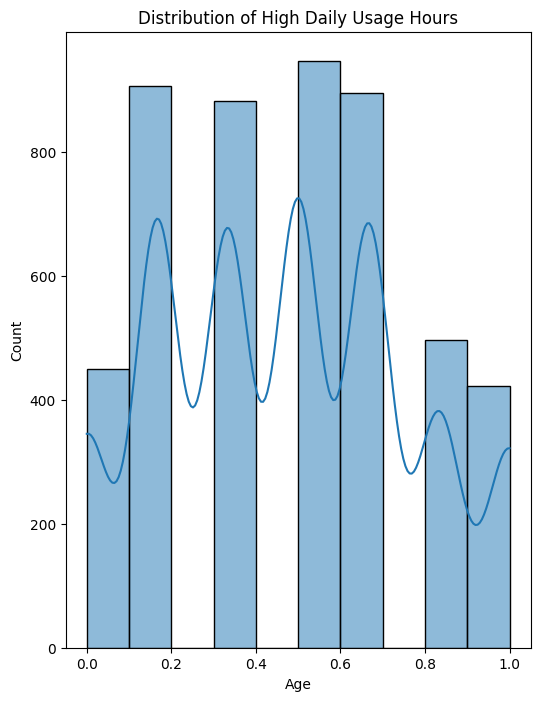

In [ ]:
plt.figure(figsize=(6,8))
sns.histplot(data['Age'],bins=10,kde=True)
plt.title('Distribution of High Daily Usage Hours')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

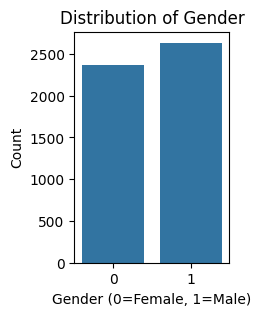

In [ ]:
plt.figure(figsize=(2,3))
sns.countplot(x='Gender',data=data)
plt.title('Distribution of Gender')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('Count')
plt.show()

In [ ]:
q1=data['Age'].quantile(0.25)
q3=data['Age'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
data=data[(data['Age']>=lower_bound)&(data['Age']<=upper_bound)]
print('Outliers removed')

Outliers removed


In [ ]:
print("Dataset shape After removing outliers:",data.shape)

Dataset shape After removing outliers: (5000, 12)


In [ ]:
print(data.columns)

# Remove duplicate rows
data.drop_duplicates(inplace=True)

# Remove missing values
data.dropna(inplace=True)

print("Data cleaned successfully")

Index(['Age', 'Gender', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Total_Activity_Hours',
       'Is_Low_Activity', 'Is_High_Usage_Hours'],
      dtype='object')
Data cleaned successfully


In [ ]:
print("Before preprocessing")
display(data.head(20))
print("After preprocessing")
display(data.head(20))

Before preprocessing


,Age,Gender,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Total_Activity_Hours,Is_Low_Activity,Is_High_Usage_Hours
0,0.500000,1,Undergraduate,Facebook,Networking,0.384615,134,4.5,2.2,6.7,0,0
1,0.833333,0,Graduate,LinkedIn,Education,0.076923,73,7.0,2.4,9.4,0,0
2,0.666667,1,Undergraduate,Instagram,Entertainment,0.461538,166,4.0,1.8,5.8,0,0
3,0.000000,1,High School,Snapchat,Entertainment,0.769231,220,1.0,1.7,2.7,1,1
4,1.000000,0,Graduate,Facebook,Networking,0.833333,237,1.0,1.1,2.1,1,1
5,0.166667,0,Undergraduate,Twitter,News,0.397436,138,4.6,2.2,6.8,0,0
6,0.666667,0,Undergraduate,Instagram,Entertainment,0.897436,246,1.0,0.9,1.9,1,1
7,0.500000,0,Undergraduate,Facebook,Networking,0.641026,209,1.0,1.3,2.3,1,1
8,1.000000,1,Graduate,YouTube,Education,0.474359,154,2.4,1.1,3.5,1,0
9,0.166667,1,Undergraduate,TikTok,Entertainment,0.333333,130,3.7,1.1,4.8,0,0


After preprocessing


,Age,Gender,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Total_Activity_Hours,Is_Low_Activity,Is_High_Usage_Hours
0,0.500000,1,Undergraduate,Facebook,Networking,0.384615,134,4.5,2.2,6.7,0,0
1,0.833333,0,Graduate,LinkedIn,Education,0.076923,73,7.0,2.4,9.4,0,0
2,0.666667,1,Undergraduate,Instagram,Entertainment,0.461538,166,4.0,1.8,5.8,0,0
3,0.000000,1,High School,Snapchat,Entertainment,0.769231,220,1.0,1.7,2.7,1,1
4,1.000000,0,Graduate,Facebook,Networking,0.833333,237,1.0,1.1,2.1,1,1
5,0.166667,0,Undergraduate,Twitter,News,0.397436,138,4.6,2.2,6.8,0,0
6,0.666667,0,Undergraduate,Instagram,Entertainment,0.897436,246,1.0,0.9,1.9,1,1
7,0.500000,0,Undergraduate,Facebook,Networking,0.641026,209,1.0,1.3,2.3,1,1
8,1.000000,1,Graduate,YouTube,Education,0.474359,154,2.4,1.1,3.5,1,0
9,0.166667,1,Undergraduate,TikTok,Entertainment,0.333333,130,3.7,1.1,4.8,0,0


In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
x='Most_Used_Platform',
y='Mental_Health_Score',
data=data
)

plt.title("Average Mental Health Score by Platform")

plt.show()

NameError: name 'data' is not defined

<Figure size 800x500 with 0 Axes>